In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt
import string
import math
import random
from multiprocessing import Pool
import os
df = pd.read_csv('names.txt')

In [2]:
#Tokenizing function with start and end chars as a 0

def tokenize(df):
    words = df.iloc[:, 0].tolist() #Can literally just convert to a list
    words = [[ord(char.lower()) - 96 for char in str(l)] for l in words] #I think ord gets asci num    
    names = []
    for i in range(len(df)):
        word = words[i]
        tokens = []
        for x in range(len(word)):
            if x == 0:
                tokens.append([0, 0, word[x]])
            elif x == 1:
                tokens.append([0, word[x-1], word[x]])
            else:
                tokens.append([word[x-2], word[x-1], word[x]])
        tokens.append([word[-2], word[-1], 0])
        tokens.append([word[x],0, 0,]) 
        names.append(tokens)
    return names

In [3]:
#Activation Functions
def tanh(x):
    e = math.e
    y = ((e**x)- (e**-x))-((e**x) + (e**-x))
    return y
def softmax(x):
    # Subtracting np.max(x) prevents numeric overflow with large exponents
    exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=-1, keepdims=True)

In [4]:
#Batching Function
def batch(x):
    x_copy = list(x)
    random.shuffle(x_copy) #Shuffles highest order of items in a list
    done = 0
    batches = []
    while done < len(x_copy):
        batches.append(x_copy[done : done + 16])
        done += 16
    return batches

In [5]:
#BatchNorm Layer
def BatchNorm(ya, beta, x):
    #Batch Norm Function I hope
    mean = np.mean(x, axis = 0, keepdims = True)
    variance = np.var(x, axis = 0, keepdims = True)
    norm = (x - mean)/np.sqrt(variance + 1e-5)
    out = ya*norm + beta
    return out, norm, variance

In [6]:
def batchnorm_backward(g, norm, gamma, var, eps=1e-5):
    N = g.shape[0]
    dbeta  = np.sum(g, axis=0, keepdims=True)
    dgamma = np.sum(g * norm, axis=0, keepdims=True)
    dx = (gamma / (N * np.sqrt(var + eps))) * (
        N * g - dbeta - norm * dgamma
    )
    return dx, dgamma, dbeta

In [7]:
def backprop(w1, w2, w3, b1, b2, b3, flat, t1, t2, y, yi,
             ya1, ya2, ya3, beta1, beta2, beta3, lr,
             norm1, norm2, norm3, var1, var2, var3):
    # delta3 = dL/d(BN3 output) -- softmax+CE shortcut, still correct
    g3 = (yi - y)
    dx3, dya3, dbeta3 = batchnorm_backward(g3, norm3, ya3, var3)
    # dx3 is dL/d(linear3 output) -- no tanh on this layer

    N = flat.shape[0]
    dw3 = (1/N) * np.dot(t2.T, dx3)
    db3 = (1/N) * np.sum(dx3, axis=0, keepdims=True)

    g2 = np.dot(dx3, w3.T)                      # dL/d(BN2 output)
    dx2_bn, dya2, dbeta2 = batchnorm_backward(g2, norm2, ya2, var2)
    dx2 = dx2_bn * (1 - t2 ** 2)                 # now apply tanh' at the RIGHT point
    dw2 = (1/N) * np.dot(t1.T, dx2)
    db2 = (1/N) * np.sum(dx2, axis=0, keepdims=True)

    g1 = np.dot(dx2, w2.T)                       # dL/d(BN1 output)
    dx1_bn, dya1, dbeta1 = batchnorm_backward(g1, norm1, ya1, var1)
    dx1 = dx1_bn * (1 - t1 ** 2)
    dw1 = (1/N) * np.dot(flat.T, dx1)
    db1 = (1/N) * np.sum(dx1, axis=0, keepdims=True)

    w1 -= dw1*lr; w2 -= dw2*lr; w3 -= dw3*lr
    b1 -= db1*lr; b2 -= db2*lr; b3 -= db3*lr
    beta1 -= dbeta1*lr; beta2 -= dbeta2*lr; beta3 -= dbeta3*lr
    ya1 -= dya1*lr; ya2 -= dya2*lr; ya3 -= dya3*lr

    return w1,w2,w3,b1,b2,b3,ya1,ya2,ya3,beta1,beta2,beta3

In [8]:
#Get the next token
def target(x):
    matches = (em == x).all(axis=1)
    cords = np.where(matches)[0]
    target1 = cords[0]
    target = np.zeros((1,27), dtype=float)
    target[0,target1] = 1.0
    return target

In [9]:
def process(w1,w2,w3,b1,b2,b3,inputs):
    if __name__ == '__main__':
        args_list = [(batch, w, b, act, is_train) for batch in batches]

In [10]:
#Embedding function that looks up one value at a time
def embed(input1, em):
    x = em[input1]
    return x

In [11]:
#Shuffle df
df = df.sample(frac = 1).reset_index(drop=True) #This samples a df randomly and resets the indexes.

#Split df
train = df[:25625]
val = df[25625:28828]
test = df[28828:]

#Tokenize Data
train = tokenize(train)
val = tokenize(val)
test = tokenize(test)



In [12]:
#Training function
def forward(w1,w2,w3,b1,b2,b3,ya1, ya2, ya3, beta1, beta2, beta3, inputs):
    flat = inputs.reshape(1, 12)
    
    x1 = (flat @ w1) + b1
    x1 = tanh(x1)
    x1, norm1, var1 = BatchNorm(ya1, beta1, x1)  
    
    x2 = (x1 @ w2) + b2
    x2 = tanh(x2)
    x2, norm2, var2 = BatchNorm(ya2, beta2, x2) 
    
    x3 = (x2 @ w3) + b3
    x3, norm3, var3 = BatchNorm(ya3, beta3, x3)
    
    yi = softmax(x3)
    
    return flat, x1, x2, norm1,norm2,norm3, yi, var1,var2,var3

In [13]:
#Create embedding matrix:
rng = np.random.default_rng()
em = rng.random(size =(27,4))

#Embed the values by running a for loop over every value and applying the embed function to it
train  = [[embed(x,em) for x in l] for l in train]
val  = [[embed(x,em) for x in l] for l in val] 
test =[[embed(x,em) for x in l] for l in test]

#Make token lists into an array
train  = [np.array(x) for x in train]
val  = [np.array(x) for x in val]
test  = [np.array(x) for x in test]

In [14]:
#Combine embedding arrays into input tensors.
train  = [np.array(x) for x in train]
val  = [np.array(x) for x in val]
test  = [np.array(x) for x in test]

In [15]:
#Initialize Weights and biases
w1 = rng.random(size =(12,128))
w2 = rng.random(size =(128,128))
w3 =rng.random(size =(128,27))

b1 = rng.random(size= (1,128))
b2 = rng.random(size= (1,128))
b3 = rng.random(size= (1,27))

ya1 = rng.random(size = (1, 128))
ya2 = rng.random(size = (1, 128))
ya3 = rng.random(size = (1, 27))

beta1 = rng.random(size = (1, 128))
beta2 = rng.random(size = (1, 128))
beta3 = rng.random(size = (1, 27))

In [19]:
epochs = 10
#Lists that keep track of backprop updates
lt, lv, ltt, lrl = [], [], [], []
w1l, w2l, w3l, b1l, b2l, b3l = [], [], [], [], [], []
beta1l, beta2l, beta3l,ya1l, ya2l,ya3l = [], [], [], [], [], []
lr = 0.0001
precl = []
recl = []


#Training Loop on train set
for e in range(epochs):   
    trainb = batch(train)
    valb = batch(val)   
    tp = 0
    tn = 0
    fp = 0
    fn = 0
    for tr in (trainb):
        for sequence in tr:
            batch_loss = []
            for t in range(len(sequence)- 1):
                flat, x1, x2, norm1, norm2, norm3, yi, var1,var2,var3 = forward(w1,w2,w3,b1,b2,b3,ya1, ya2, ya3, beta1, beta2, beta3, sequence[t])
                
                y = target(sequence[t+1][2])    
                loss = -1 * np.sum(y * np.log(yi))  
                batch_loss.append(loss)
                
            w1,w2,w3,b1,b2,b3,ya1,ya2,ya3,beta1,beta2,beta3 = backprop(w1, w2, w3, b1, b2, b3, flat, x1, x2, y, yi, ya1, ya2, ya3, beta1, beta2, beta3, lr,norm1, norm2, norm3, var1, var2, var3)

            beta1l.append(beta1) 
            beta2l.append(beta2) 
            beta3l.append(beta3)
            ya1l.append(ya1) 
            ya2l.append(ya2)
            ya3l.append(ya3)

            w1l.append(w1)
            w2l.append(w2)
            w3l.append(w3)
            b1l.append(b1)
            b2l.append(b2)
            b3l.append(b3)

            lr *= 0.99
            lrl.append(lr)
            lt.append(np.array(batch_loss).mean())
    print("Epoch completed final loss was: " + str(lt[-1])) 
    #Val loop
    for v in valb:
        for sequence in v:
            for t in range(len(sequence)-1):
                    flat, x1, x2, norm1, norm2, norm3, yi, var1,var2,var3 = forward(w1,w2,w3,b1,b2,b3,ya1, ya2, ya3, beta1, beta2, beta3, sequence[t])
                    
                    y = target(sequence[t+1][2])
                    loss = -1 * np.sum(y * np.log(yi))  
                    lv.append(loss)

Epoch completed final loss was: 3.1664456851986773
Epoch completed final loss was: 3.2014386582300043
Epoch completed final loss was: 3.2396496177983316
Epoch completed final loss was: 3.2295464509086336
Epoch completed final loss was: 3.1714270967124065
Epoch completed final loss was: 3.2717052767953994
Epoch completed final loss was: 3.2931858584935716
Epoch completed final loss was: 3.2362767865175726
Epoch completed final loss was: 3.1905150987233415
Epoch completed final loss was: 3.319876626560558


In [20]:
#Inference loop
for i in range(epochs):
    testb = batch(test)
    for i in testb:
        for sequence in i :
            for t in range(len(sequence)- 1):
                flat, x1, x2, norm1, norm2, norm3, yi, var1,var2,var3 = forward(w1,w2,w3,b1,b2,b3,ya1, ya2, ya3, beta1, beta2, beta3, sequence[t])       
                y = target(sequence[t+1][2])
                loss = -1 * np.sum(y * np.log(yi))  
                ltt.append(loss)

In [21]:
#Graphing Function
def graph(lt, lv, ltt, lrl,w1l,w2l,w3l, b1l, b2l, b3l,beta1l, beta2l, beta3l, ya1l, ya2l,ya3l):

    #Graph Losses
    plt.figure(figsize=(10, 5))
    plt.plot(lt, label='Training Loss (per step)', alpha=0.5)
    if lv:
        plt.plot(lv, label='Validation Loss (per step)', alpha=0.5)
    if ltt:
        plt.plot(ltt, label='Test Loss (per step)', alpha=0.5)
    plt.xlabel('Steps')
    plt.ylabel('Categorical Cross-Entropy Loss')
    plt.title('Loss Trajectory')
    plt.legend()
    plt.show()

    '''

    Can't graph weights directly need to use stats. If you flatten them into a list then the kernel will crash. I can probably 
    find other stats in this way. 
    
    '''
    
    #Graph Weights
    plt.plot([np.mean(w) for w in w1l], label='W1 Mean')
    plt.plot([np.mean(w) for w in w2l], label='W2 Mean')
    plt.plot([np.mean(w) for w in w3l], label='W3 Mean')
    plt.title('Weight Means over Steps')
    plt.legend()
    plt.show()

    #Graph Biases
    plt.figure(figsize=(10, 4))
    plt.plot([np.mean(b) for b in b1l], label='B1 Mean')
    plt.plot([np.mean(b) for b in b2l], label='B2 Mean')
    plt.plot([np.mean(b) for b in b3l], label='B3 Mean')
    plt.title('Bias Means over Steps')
    plt.legend()
    plt.show()
    
    #Graph Gammas
    plt.plot([np.mean(y) for b in ya1l], label='Y1 Mean')
    plt.plot([np.mean(y) for b in ya2l], label='Y2 Mean')
    plt.plot([np.mean(y) for b in ya3l], label='Y3 Mean')
    plt.title('Gamma Means over Steps')
    plt.legend()
    plt.show()

    #Graph Betas
    plt.plot(epochs, beta1)
    plt.plot(epochs, beta2)
    plt.plot(epochs, beta3)
    plt.show()

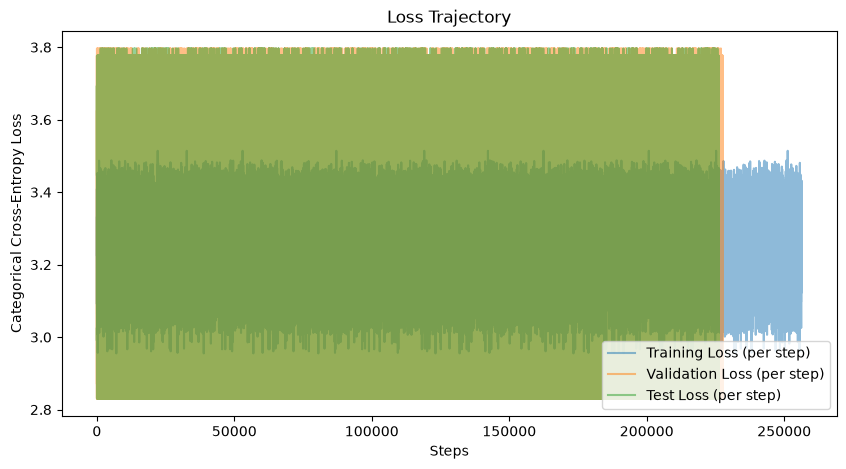

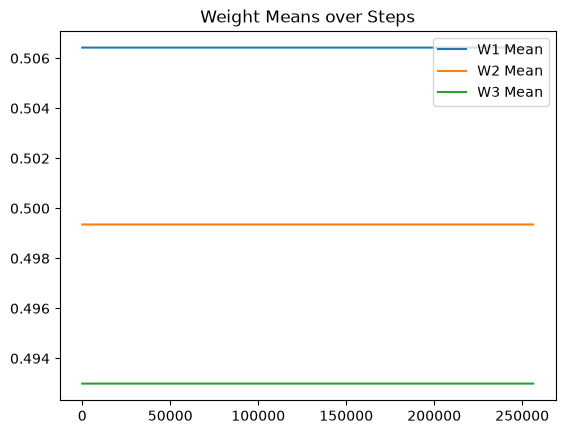

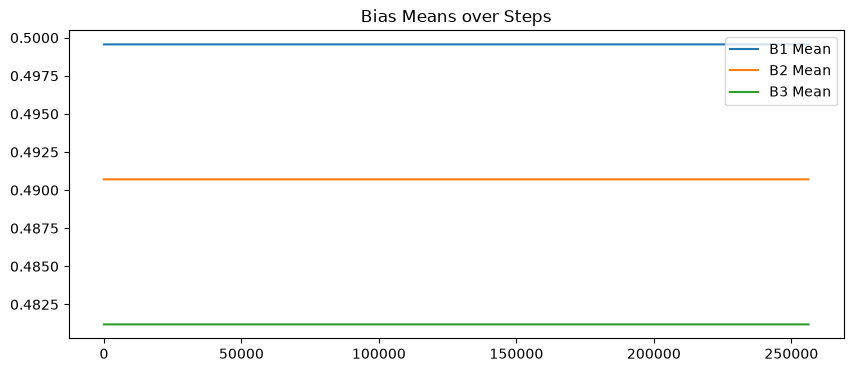

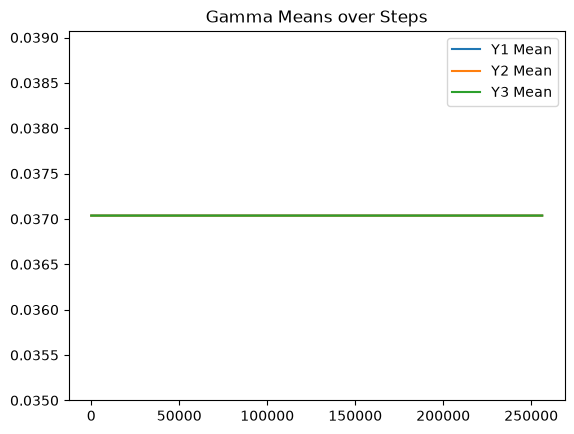

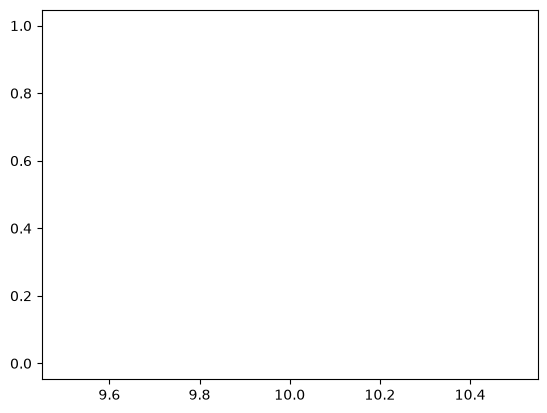

In [22]:
graph(lt, lv, ltt, lrl,w1l,w2l,w3l, b1l, b2l, b3l,beta1l, beta2l, beta3l, ya1l, ya2l,ya3l)